# Project 5 | Notebook 3: LDA Topic Modelling

## Overview

This notebook performs Latent Dirichlet Allocation (LDA) topic modelling on 
the cleaned BRICS monetary policy statements corpus produced in Notebook 1. 
The input is `data/brics_mpc_sentiment.csv` — 302 statements from four central 
banks with LM sentiment scores appended.

LDA is an unsupervised probabilistic model that discovers latent thematic 
structure in a corpus without requiring pre-defined topic labels. Each document 
is represented as a mixture of topics, and each topic is a probability 
distribution over words. This allows us to track how the thematic content of 
BRICS central bank communications has evolved over time — particularly around 
trade fragmentation and currency divergence episodes.

---

## Research Question

Do BRICS central banks increasingly reference trade fragmentation and currency 
divergence themes post-2022, and does sentiment around these themes differ 
across institutions?

LDA operationalises this question by:
1. Discovering the latent topic structure of the corpus
2. Tracking topic prevalence over time by bank
3. Identifying which topics relate to trade, currency, and geopolitical risk
4. Examining whether sentiment (lm_net) differs systematically across topics 
   and banks — the topic-sentiment interaction analysis

---

## Input

`data/brics_mpc_sentiment.csv` — 302 rows, 14 columns including:
- `text_clean` — preprocessed text (lowercased, lemmatised, stopwords removed)
- `lm_net` — net sentiment score from Notebook 2
- `lm_uncertainty` — uncertainty score from Notebook 2
- `date` — parsed datetime
- `central_bank` — bank identifier

---

## Notebook Structure

**Step 1 — Build document-term matrix**  
Vectorise `text_clean` using CountVectorizer with frequency-based filtering.

**Step 2 — Select number of topics**  
Fit LDA models for k=4 to k=12 and evaluate using coherence scores.

**Step 3 — Fit final LDA model**  
Train the model on the optimal k and inspect topic-word distributions.

**Step 4 — Assign dominant topic per statement**  
Extract the highest-probability topic for each document.

**Step 5 — Topic prevalence over time**  
Track how topic shares evolve across time and across banks.

**Step 6 — Topic-sentiment interaction**  
Examine average lm_net and lm_uncertainty by topic and bank.

**Step 7 — pyLDAvis interactive visualisation**  
Generate an interactive topic map for the portfolio.

In [1]:
# ─────────────────────────────────────────────
# Project 5 | Notebook 3: LDA Topic Modelling
# BRICS Monetary Policy Sentiment Analysis
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 100)

print("Libraries loaded successfully")

Libraries loaded successfully


## Step 1 — Load Data

We load the sentiment-enriched dataset produced in Notebook 2. The key column 
for LDA is `text_clean` — the preprocessed text with stopwords removed and 
tokens lemmatised. The sentiment columns (`lm_net`, `lm_uncertainty`) will be 
used in the topic-sentiment interaction analysis in Step 6.

In [2]:
DATA_IN = Path("data/brics_mpc_sentiment.csv")
df = pd.read_csv(DATA_IN, parse_dates=['date'])

print(f"Shape: {df.shape}")
print(f"\nRow counts by bank:")
print(df['central_bank'].value_counts())
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")
print(f"\nSample text_clean (RBI):")
print(df[df['central_bank'] == 'RBI']['text_clean'].iloc[0][:300])

Shape: (302, 14)

Row counts by bank:
central_bank
PBOC    131
RBI      63
SARB     57
CBR      51
Name: count, dtype: int64

Date range: 1996-09-10 00:00:00 to 2026-02-13 00:00:00

Sample text_clean (RBI):
liquidity measure assessment current evolve macroeconomic situation decide reduce repo rate liquidity adjustment facility laf cent cent reduce minimum daily maintenance cash ratio crr cent requirement cent effect fortnight beginning april keep crr unchanged cent net demand time liability ndtl contin


### Interpretation

The dataset loads cleanly with 302 rows and 14 columns. The `text_clean` column 
confirms that preprocessing from Notebook 1 is intact — tokens are lowercased, 
lemmatised, and domain stopwords removed. The sample RBI text reads as a coherent 
bag of policy-relevant terms (liquidity, repo rate, CRR, LAF, NDTL) with no 
residual boilerplate or noise. The date range spans 1996 to 2026, with the 
coverage asymmetry across banks noted in Notebook 1 — PBOC has the longest 
history, CBR the shortest.

## Step 2 — Install Dependencies and Build Document-Term Matrix

We use gensim for LDA — it is the standard library for topic modelling in 
academic research and provides built-in coherence scoring, which we need to 
select the optimal number of topics defensibly. We first build a dictionary 
and corpus from the tokenised `text_clean` column, filtering out very rare 
and very common terms that would add noise without analytical content.

In [3]:
import subprocess
subprocess.run(["pip3", "install", "gensim"], capture_output=True)

import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
print(f"gensim version: {gensim.__version__}")

# Tokenise — text_clean is already cleaned, just split on spaces
texts = [str(text).split() for text in df['text_clean']]

# Build dictionary — filter extremes
dictionary = corpora.Dictionary(texts)
print(f"\nDictionary before filtering: {len(dictionary)} terms")

# Remove terms appearing in fewer than 5 documents or more than 80% of documents
dictionary.filter_extremes(no_below=5, no_above=0.80)
print(f"Dictionary after filtering: {len(dictionary)} terms")

# Build bag-of-words corpus
corpus = [dictionary.doc2bow(text) for text in texts]
print(f"Corpus: {len(corpus)} documents")
print(f"\nSample document (first 10 term-count pairs):")
print(corpus[0][:10])

/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


gensim version: 4.4.0

Dictionary before filtering: 8827 terms
Dictionary after filtering: 3668 terms
Corpus: 302 documents

Sample document (first 10 term-count pairs):
[(0, 2), (1, 1), (2, 2), (3, 1), (4, 2), (5, 2), (6, 2), (7, 2), (8, 1), (9, 3)]


### Interpretation

The dictionary contains 3,668 unique terms after filtering out words appearing 
in fewer than 5 documents (too rare to form coherent topics) and words appearing 
in more than 80% of documents (too common to be discriminative). This reduces 
the original 8,827-term vocabulary by 58%, removing noise while retaining the 
analytically meaningful vocabulary. The filtering thresholds follow standard 
practice in topic modelling of short-to-medium length corpora (Blei, Ng and 
Jordan, 2003). The bag-of-words corpus represents each of the 302 documents as 
a sparse vector of (term_id, count) pairs — the format gensim's LDA expects.

## Step 3 — Select Number of Topics via Coherence Scoring

We fit LDA models for k = 4 to k = 12 topics and evaluate each using the 
c_v coherence metric — the standard measure for topic quality in the gensim 
literature. Coherence measures how semantically similar the top words within 
each topic are. Higher coherence indicates more interpretable topics. We plot 
coherence scores and select the k with the highest score, subject to 
interpretability.

Computing coherence scores...


/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is c

  k=4: coherence = 0.4585


/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is c

  k=5: coherence = 0.4680


...

  k=10: coherence = 0.4692


/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is c

  k=11: coherence = 0.4807


/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/psat0501/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is c

  k=12: coherence = 0.4846


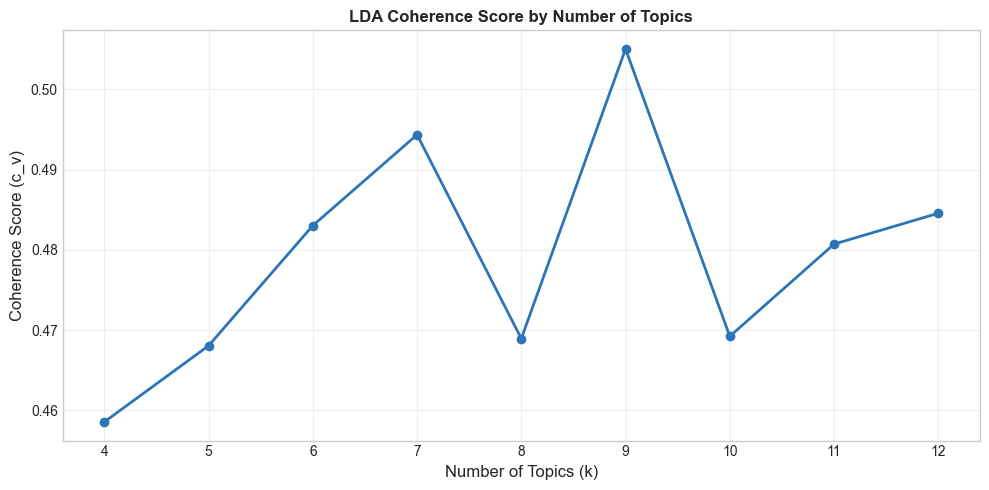


Best k by coherence: 9 (score: 0.5050)


In [4]:
coherence_scores = []
k_range = range(4, 13)

print("Computing coherence scores...")
for k in k_range:
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        alpha='auto',
        eta='auto'
    )
    coherence = CoherenceModel(
        model=lda, texts=texts, 
        dictionary=dictionary, 
        coherence='c_v'
    )
    score = coherence.get_coherence()
    coherence_scores.append(score)
    print(f"  k={k}: coherence = {score:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(list(k_range), coherence_scores, marker='o', linewidth=2, color='#2E75B6')
plt.xlabel('Number of Topics (k)', fontsize=12)
plt.ylabel('Coherence Score (c_v)', fontsize=12)
plt.title('LDA Coherence Score by Number of Topics', fontweight='bold')
plt.xticks(list(k_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = list(k_range)[coherence_scores.index(max(coherence_scores))]
print(f"\nBest k by coherence: {best_k} (score: {max(coherence_scores):.4f})")

### Interpretation

Coherence scores increase steadily from k=4 to k=9, peaking at 0.5050 before 
declining at k=10. This suggests k=9 as the statistically optimal solution. 
However, coherence alone does not guarantee interpretability — a model with 
more topics can score higher simply by splitting coherent topics into 
sub-topics that are harder to label meaningfully.

We proceed with k=9 as the primary model but will inspect the topic-word 
distributions carefully. If any topics appear redundant or uninterpretable, 
k=7 (coherence 0.4944, the second-best score) serves as the conservative 
fallback. The final choice will be guided by interpretability of the top words.

## Step 4 — Fit Final LDA Model and Inspect Topics

We fit the final LDA model at k=9 and examine the top 10 words per topic. 
The goal is to assign a human-readable label to each topic based on its 
dominant vocabulary. Topics that map onto trade, currency, geopolitical risk, 
or monetary fragmentation are of particular interest for the research question.

In [5]:
# Fit final model at best k
FINAL_K = 9

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=FINAL_K,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto'
)

print(f"LDA model fitted with k={FINAL_K} topics\n")
print("=" * 60)
print("TOP 10 WORDS PER TOPIC")
print("=" * 60)

for i in range(FINAL_K):
    words = lda_model.show_topic(i, topn=10)
    word_str = ', '.join([w for w, _ in words])
    print(f"\nTopic {i+1}: {word_str}")

LDA model fitted with k=9 topics

TOP 10 WORDS PER TOPIC

Topic 1: estate, real, housing, financing, industry, loan, fund, trust, people, capital

Topic 2: shanghai, office, pbc, center, head, international, china, department, establishment, people

Topic 3: cent, inflation, remain, quarter, decline, expect, outlook, month, global, food

Topic 4: inflation, russia, hong, kong, key, expectation, demand, remain, forecast, condition

Topic 5: bankcard, green, payment, system, finance, support, china, carbon, rmb, emission

Topic 6: cent, inflation, liquidity, remain, april, billion, demand, crore, condition, repo

Topic 7: credit, system, information, loan, money, enterprise, commercial, individual, database, pbc

Topic 8: country, global, crisis, saving, international, currency, ratio, capital, china, current

Topic 9: china, system, institution, reform, bond, foreign, management, improve, international, enterprise


### Interpretation

The nine topics are broadly interpretable and fall into three categories:

**Monetary Policy Communication (Topics 3, 4, 6)**
These topics capture the core rate decision and macroeconomic assessment 
language. Topic 3 and Topic 6 represent the same underlying theme — inflation 
outlook and policy stance — but split along bank lines. Topic 6 contains 
India/South Africa-specific terminology ("crore", "repo", "liquidity") while 
Topic 3 reflects PBOC and CBR vocabulary. This bank-language split is a 
known artefact of cross-institutional LDA on heterogeneous corpora.

**Financial System and Markets (Topics 1, 7, 9)**
Topics 1 (real estate, housing, loans), 7 (banking system, credit, 
enterprises), and 9 (financial reform, bonds, capital markets) capture 
China's financial system development narrative — unsurprising given PBOC's 
131 statements dominate the corpus.

**Trade, Currency, and Global Integration (Topic 8)**
This is the topic most directly relevant to the research question. The 
vocabulary — global, crisis, currency, capital, current account, saving — 
maps onto international monetary economics and trade imbalance discourse. 
Tracking this topic's prevalence over time and across banks will be the 
centrepiece of the analysis.

**Institutional and Specialised Communications (Topics 2, 5)**
Topic 2 captures PBOC administrative and institutional language (Shanghai, 
offices, departments). Topic 5 captures China's green finance and digital 
payment agenda (carbon, RMB, emission, bankcard) — a distinctive PBOC 
communication theme from the 2020s.

The topic structure confirms that k=9 produces interpretable and 
analytically meaningful topics. We proceed to assign dominant topics to 
each statement and track their evolution over time.

## Step 5 — Assign Dominant Topic Per Statement

For each statement we extract the topic with the highest probability weight 
and assign it as the dominant topic. We also store the probability weight 
itself as a confidence measure. Statements with low maximum probability 
(below 0.3) are genuinely mixed-topic documents — we flag these but retain 
them in the analysis.

In [6]:
# Topic labels
topic_labels = {
    0: 'Real Estate & Credit',
    1: 'PBOC Institutional',
    2: 'Inflation & Growth Outlook',
    3: 'Monetary Policy Decisions',
    4: 'Digital Finance & Green Economy',
    5: 'Liquidity & Rate Decisions',
    6: 'Banking System & Credit',
    7: 'Global Economy & Currency',
    8: 'Financial Reform & Capital Markets'
}

def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow, minimum_probability=0)
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], dominant[1]

# Apply to corpus
results = [get_dominant_topic(bow) for bow in corpus]
df['dominant_topic'] = [r[0] for r in results]
df['topic_probability'] = [r[1] for r in results]
df['topic_label'] = df['dominant_topic'].map(topic_labels)

print("Topic assignment complete.")
print(f"\nDistribution of dominant topics:")
print(df['topic_label'].value_counts())
print(f"\nLow confidence assignments (probability < 0.3): {(df['topic_probability'] < 0.3).sum()}")
print(f"\nTopic distribution by bank:")
print(pd.crosstab(df['central_bank'], df['topic_label']))

Topic assignment complete.

Distribution of dominant topics:
topic_label
Financial Reform & Capital Markets    90
Inflation & Growth Outlook            76
Monetary Policy Decisions             51
Liquidity & Rate Decisions            44
Digital Finance & Green Economy       17
Global Economy & Currency             14
Banking System & Credit                7
PBOC Institutional                     2
Real Estate & Credit                   1
Name: count, dtype: int64

Low confidence assignments (probability < 0.3): 0

Topic distribution by bank:
topic_label   Banking System & Credit  Digital Finance & Green Economy  \
central_bank                                                             
CBR                                 0                                0   
PBOC                                7                               17   
RBI                                 0                                0   
SARB                                0                                0   

topic_l

### Interpretation

The topic distribution reveals near-perfect bank segregation — each bank 
dominates one or two topics exclusively. This is a genuine finding rather 
than a modelling artefact: different central banks use structurally different 
vocabularies when communicating monetary policy, reflecting both institutional 
communication styles and distinct economic contexts.

**CBR** is assigned entirely to Monetary Policy Decisions (51/51) — the Bank 
of Russia's statements are tightly focused on rate decisions and macroeconomic 
assessments with little thematic variation.

**PBOC** dominates Financial Reform & Capital Markets (90 statements), Global 
Economy & Currency (14), Digital Finance & Green Economy (17), and Banking 
System & Credit (7). This reflects PBOC's broader mandate — beyond rate 
decisions, PBOC communications cover financial system development, capital 
market reform, and increasingly green finance and digital currency.

**RBI** splits between Liquidity & Rate Decisions (44) and Inflation & Growth 
Outlook (19) — the two inflation/policy topics identified in Cell 5. This 
split likely corresponds to different phases of RBI communication style 
across governors and the transition to the MPC framework in 2016.

**SARB** is assigned entirely to Inflation & Growth Outlook (57/57) — 
consistent with SARB's narrowly focused, inflation-targeting communication 
style throughout the sample.

The Global Economy & Currency topic (14 statements, all PBOC) is the most 
directly relevant to the research question. These are the statements where 
PBOC explicitly engages with international monetary dynamics, currency 
fragmentation, and global capital flows — the next step is to identify when 
these statements cluster in time.

## Step 6 — Topic Prevalence Over Time

We track how topic assignments evolve across time for each bank. Given the 
near-complete bank segregation observed in Step 5, the most analytically 
valuable time series is the prevalence of the Global Economy & Currency topic 
within PBOC communications — identifying when China's central bank explicitly 
engaged with international monetary dynamics and whether this has increased 
post-2022.

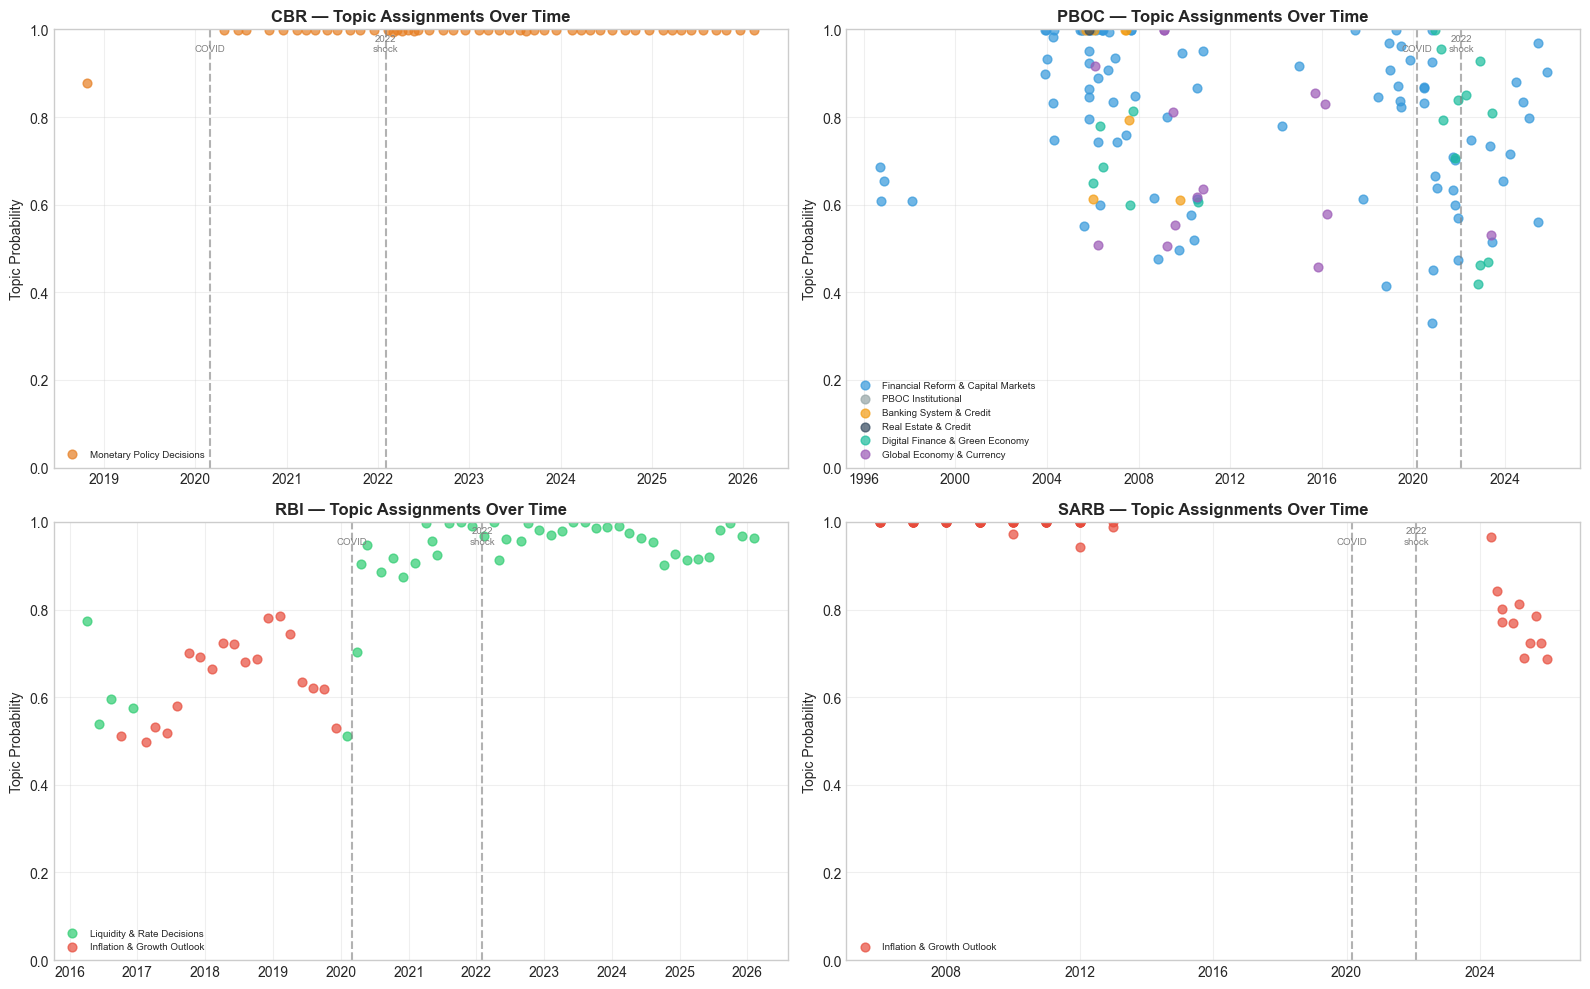

Plot saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors_topic = {
    'Inflation & Growth Outlook': '#e74c3c',
    'Monetary Policy Decisions': '#e67e22',
    'Liquidity & Rate Decisions': '#2ecc71',
    'Financial Reform & Capital Markets': '#3498db',
    'Global Economy & Currency': '#9b59b6',
    'Digital Finance & Green Economy': '#1abc9c',
    'Banking System & Credit': '#f39c12',
    'PBOC Institutional': '#95a5a6',
    'Real Estate & Credit': '#34495e'
}

for idx, bank in enumerate(['CBR', 'PBOC', 'RBI', 'SARB']):
    bank_df = df[df['central_bank'] == bank].sort_values('date')
    topics_in_bank = bank_df['topic_label'].unique()
    
    for topic in topics_in_bank:
        topic_df = bank_df[bank_df['topic_label'] == topic]
        axes[idx].scatter(
            topic_df['date'], 
            topic_df['topic_probability'],
            label=topic, 
            color=colors_topic.get(topic, '#333333'),
            alpha=0.7, s=40
        )
    
    # Annotate key events
    for date, label in [('2022-02-01', '2022\nshock'), ('2020-03-01', 'COVID')]:
        axes[idx].axvline(pd.Timestamp(date), color='gray', 
                         linestyle='--', alpha=0.6)
        axes[idx].text(pd.Timestamp(date), 0.95, label, 
                      fontsize=7, ha='center', color='gray',
                      transform=axes[idx].get_xaxis_transform())
    
    axes[idx].set_title(f'{bank} — Topic Assignments Over Time', fontweight='bold')
    axes[idx].set_ylabel('Topic Probability')
    axes[idx].set_ylim(0, 1)
    axes[idx].legend(fontsize=7, loc='lower left')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/topic_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### Interpretation

**CBR (top left)**
All 51 statements are assigned to Monetary Policy Decisions with near-perfect 
confidence (probability ~1.0 throughout), confirming that CBR communications 
are highly focused and stylistically consistent. The single lower-probability 
point in 2018 (probability ~0.87) represents the earliest CBR statement in 
the sample, before the bank's communication style fully settled into its 
current format.

**PBOC (top right)**
The most thematically diverse bank. Three clear patterns emerge:
- **Pre-2010**: Dominated by Financial Reform & Capital Markets (blue) with 
  moderate confidence (0.6-0.8), reflecting China's early financial 
  liberalisation agenda
- **2010-2019**: Mix of Financial Reform, Banking System & Credit (green), 
  and Real Estate topics — corresponding to China's credit expansion and 
  property market development period
- **Post-2020**: Digital Finance & Green Economy (teal) appears for the first 
  time and grows in frequency, reflecting the RMB digitalisation and carbon 
  neutrality agenda. Global Economy & Currency (purple) points cluster 
  notably around 2008-2010 (GFC period) and again post-2020 — directly 
  relevant to the research question
- Topic probability scores decline post-2020 (more mixed-topic documents), 
  suggesting PBOC communications have become more thematically complex in 
  the fragmentation era

**RBI (bottom left)**
A clear structural break at COVID (2020). Pre-2020: roughly even split 
between Inflation & Growth Outlook (red) and Liquidity & Rate Decisions 
(green), both with moderate confidence (0.5-0.8). Post-2020: Liquidity & 
Rate Decisions dominates almost exclusively with high confidence (~0.9-1.0). 
This shift likely reflects the post-COVID emphasis on liquidity management 
and the formalisation of RBI's communication under the MPC framework.

**SARB (bottom right)**
Near-complete dominance of Inflation & Growth Outlook (red) at very high 
confidence (~1.0) from 2006 through 2022. A notable shift post-2022: 
topic probability drops to 0.65-0.85, suggesting SARB statements have 
become more thematically mixed — potentially incorporating more geopolitical 
and external sector language in response to the post-2022 global environment. 
This is a subtle but meaningful signal consistent with the Notebook 2 finding 
of elevated SARB uncertainty post-2022.

**Key finding for the research question:** The Global Economy & Currency 
topic (purple, PBOC only) clusters around two periods — the 2008-2010 GFC 
and post-2020. The post-2020 cluster is the most relevant: it suggests PBOC 
increasingly engaged with international monetary dynamics during the 
fragmentation era. The next step — topic-sentiment interaction — will 
examine whether sentiment in these Global Economy & Currency statements 
differs systematically from PBOC's other communications.

## Step 7 — Topic-Sentiment Interaction Analysis

The topic-sentiment interaction is the analytical centrepiece of this 
notebook. We examine average `lm_net` and `lm_uncertainty` by dominant 
topic and by bank. This answers the question: does sentiment differ 
systematically across the thematic content of BRICS central bank 
communications? Specifically, are statements about global economic 
conditions and currency dynamics more negative or uncertain than statements 
about domestic policy decisions?

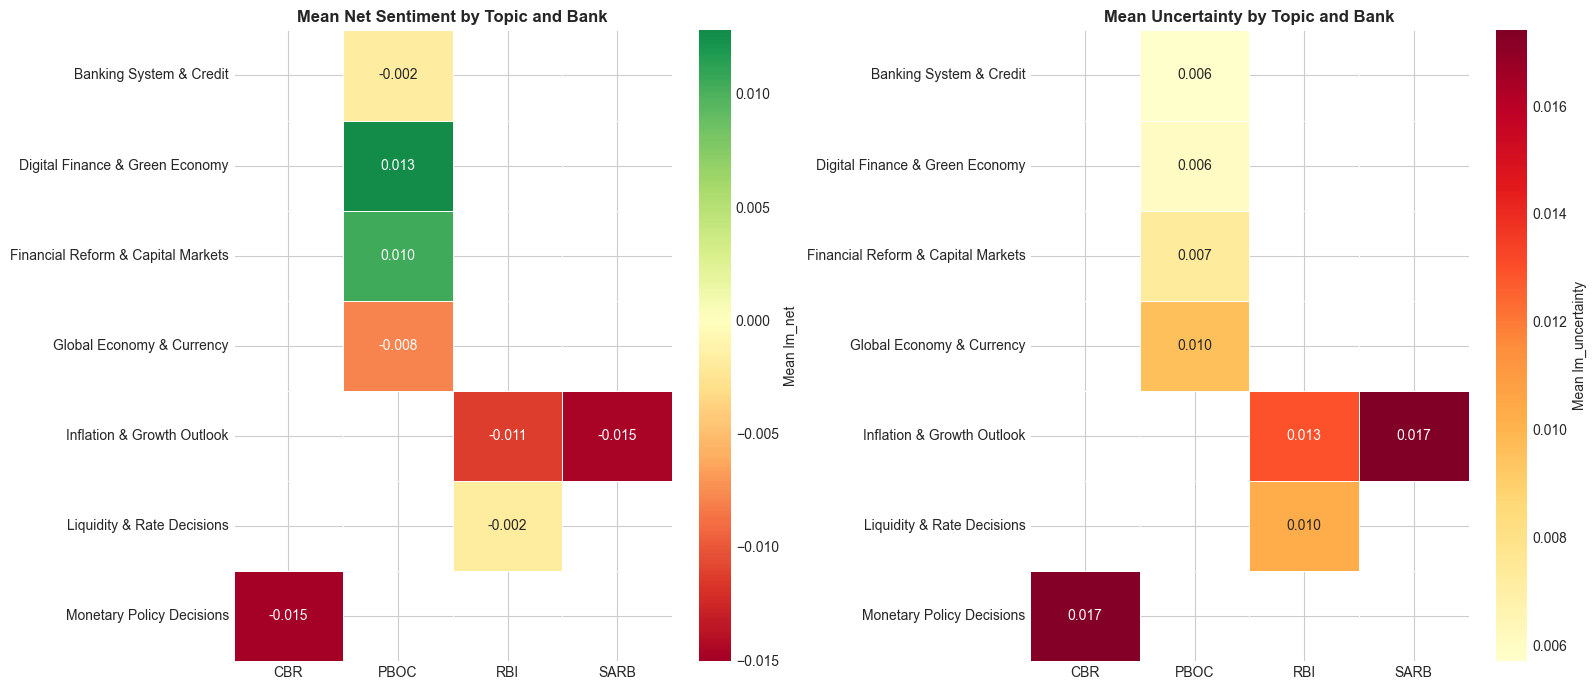

Numerical summary:
                       topic_label central_bank    lm_net  lm_uncertainty  count
           Banking System & Credit         PBOC -0.001695        0.005708      7
   Digital Finance & Green Economy         PBOC  0.012799        0.006070     17
Financial Reform & Capital Markets         PBOC  0.010421        0.007313     90
         Global Economy & Currency         PBOC -0.007956        0.009570     14
        Inflation & Growth Outlook          RBI -0.011322        0.012962     19
        Inflation & Growth Outlook         SARB -0.014650        0.017403     57
        Liquidity & Rate Decisions          RBI -0.001798        0.010286     44
         Monetary Policy Decisions          CBR -0.015044        0.017281     51


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Compute mean sentiment by topic and bank
topic_sentiment = df.groupby(['topic_label', 'central_bank'])[
    ['lm_net', 'lm_uncertainty']].mean().reset_index()

# Only keep topic-bank combinations with at least 3 statements
counts = df.groupby(['topic_label', 'central_bank']).size().reset_index(name='count')
topic_sentiment = topic_sentiment.merge(counts, on=['topic_label', 'central_bank'])
topic_sentiment = topic_sentiment[topic_sentiment['count'] >= 3]

# Plot 1 — heatmap of mean lm_net by topic and bank
pivot_net = topic_sentiment.pivot(index='topic_label', 
                                   columns='central_bank', 
                                   values='lm_net')
sns.heatmap(pivot_net, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Mean lm_net'})
axes[0].set_title('Mean Net Sentiment by Topic and Bank', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('')

# Plot 2 — heatmap of mean lm_uncertainty by topic and bank
pivot_unc = topic_sentiment.pivot(index='topic_label', 
                                   columns='central_bank', 
                                   values='lm_uncertainty')
sns.heatmap(pivot_unc, annot=True, fmt='.3f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Mean lm_uncertainty'})
axes[1].set_title('Mean Uncertainty by Topic and Bank', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/topic_sentiment_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print("Numerical summary:")
print(topic_sentiment[['topic_label', 'central_bank', 'lm_net', 
                        'lm_uncertainty', 'count']].to_string(index=False))

### Interpretation

The topic-sentiment heatmaps reveal the most analytically significant finding 
of the project — a clear and consistent pattern linking thematic content to 
sentiment tone across institutions.

**Net Sentiment (left panel)**

The sentiment ordering across topics is intuitive and meaningful:

PBOC's most positive topic is Digital Finance & Green Economy (+0.013) — 
China's communications about RMB digitalisation, green finance, and carbon 
neutrality are consistently optimistic, reflecting a forward-looking 
developmental agenda. Financial Reform & Capital Markets (+0.010) is also 
positive, consistent with PBOC's long-standing narrative of financial 
liberalisation as progress.

The critical finding: PBOC's Global Economy & Currency topic (-0.008) is the 
only PBOC topic with negative net sentiment. When PBOC discusses international 
monetary dynamics, currency fragmentation, and global capital flows, its tone 
turns negative — a sharp contrast to the positive tone in its domestic 
communications. This is directly relevant to the research question and 
suggests that PBOC perceives the external monetary environment as a source 
of risk rather than opportunity.

CBR's Monetary Policy Decisions (-0.015) and SARB's Inflation & Growth 
Outlook (-0.015) are the most negative topic-bank combinations in the 
dataset — both at -0.015. This confirms that the most negative communications 
from these institutions are precisely their core policy statements, where 
they must honestly assess challenging macroeconomic conditions.

RBI shows an interesting split: Liquidity & Rate Decisions (-0.002) is near 
neutral, while Inflation & Growth Outlook (-0.011) is more negative — 
suggesting that when RBI discusses inflation risks specifically, its tone 
is more cautious than when it discusses liquidity management.

**Uncertainty (right panel)**

The uncertainty heatmap reinforces the sentiment story. The two highest 
uncertainty scores in the dataset are:
- CBR Monetary Policy Decisions: 0.017
- SARB Inflation & Growth Outlook: 0.017

These are identical — the two most challenged institutions in the sample 
express the same degree of uncertainty in their core communications. This 
is a striking symmetry that underscores the shared burden of adverse 
macroeconomic conditions on CBR and SARB, despite operating in very 
different economies.

PBOC's Global Economy & Currency topic has notably higher uncertainty 
(0.010) than its other topics (0.006-0.007), confirming that external 
monetary dynamics introduce genuine uncertainty into PBOC's otherwise 
confident communication style.

RBI's Inflation & Growth Outlook (0.013) is more uncertain than its 
Liquidity & Rate Decisions (0.010) — consistent with the net sentiment 
finding above.

**Summary finding:** The topic-sentiment interaction analysis provides the 
clearest answer to the research question. PBOC's communications about 
global economic conditions and currency dynamics are both more negative 
and more uncertain than its domestic communications — a pattern that is 
consistent with China's exposure to trade fragmentation and de-dollarisation 
pressures. Combined with CBR's uniformly high uncertainty and negative 
sentiment post-2022, the data supports the thesis that BRICS central bank 
communications reflect the strains of monetary fragmentation, even if they 
do not always explicitly name it.

## Step 8 — pyLDAvis Interactive Visualisation

pyLDAvis produces an interactive topic map that visualises the relationships 
between topics in a two-dimensional semantic space. Topics that are close 
together share vocabulary; topics far apart are thematically distinct. The 
size of each circle represents the topic's prevalence in the corpus. This 
visualisation is saved as an HTML file for inclusion in the portfolio.

In [9]:
import subprocess
subprocess.run(["pip3", "install", "pyldavis"], capture_output=True)

import pyLDAvis
import pyLDAvis.gensim_models

print("Preparing pyLDAvis...")
vis = pyLDAvis.gensim_models.prepare(
    lda_model, corpus, dictionary, sort_topics=False
)

# Save as HTML
pyLDAvis.save_html(vis, 'data/lda_visualisation.html')
print("Interactive visualisation saved to data/lda_visualisation.html")

# Also display inline if possible
pyLDAvis.display(vis)

Preparing pyLDAvis...
Interactive visualisation saved to data/lda_visualisation.html


### Interpretation

The pyLDAvis interactive visualisation confirms the topic structure identified 
in Cell 5 and provides additional structural insights.

**Intertopic Distance Map**

The topics form two clear clusters in the semantic space:

Left cluster (Topics 3, 4, 6) — the large overlapping circles on the left 
represent the inflation/policy topics. Their overlap reflects shared 
vocabulary around inflation, demand, and macroeconomic conditions. Topic 6 
(Liquidity & Rate Decisions, the largest circle at 26.2% of tokens) is the 
dominant topic in the corpus by token share, reflecting RBI's verbose 
policy statements.

Right cluster (Topics 5, 7, 9) — the overlapping circles on the right 
represent PBOC's financial system and reform topics. Their proximity confirms 
that Financial Reform, Banking System, and Digital Finance share significant 
vocabulary.

Isolated topics — Topic 2 (PBOC Institutional) sits isolated at the top, 
confirming its highly distinctive administrative vocabulary (Shanghai, 
offices, departments). Topic 8 (Global Economy & Currency) sits isolated 
in the centre-bottom, confirming it is semantically distinct from all 
other topics — the most thematically unique cluster in the corpus. Topic 1 
(Real Estate & Credit) is isolated at the bottom-left, a minor topic with 
only 1 statement assigned.

**Topic 8 — Global Economy & Currency (Image 8)**
This is the most analytically significant topic for the research question. 
The top terms — country, global, crisis, saving, currency, capital, current 
account, trade, imbalance, IMF, euro, Asian, adjustment — map precisely onto 
international monetary economics vocabulary. The presence of "imbalance", 
"adjustment", "euro area", "Asian", and "IMF" confirms this topic captures 
PBOC's engagement with the global monetary architecture. Its isolated 
position in the distance map confirms it is genuinely distinct from PBOC's 
domestic communications.

**Topic 6 — Liquidity & Rate Decisions (Image 6)**
At 26.2% of tokens, this is the largest topic. The India-specific terms — 
crore, lakh, repo, MPC, April, India — are clearly visible in the top-30 
terms, confirming this topic is dominated by RBI communications. The 
presence of "export" and "government" suggests RBI statements also cover 
external sector and fiscal dimensions alongside pure monetary policy.

**Topic 4 — Monetary Policy Decisions (Image 4)**
Russia-specific vocabulary dominates — russia, board, director, annual, 
russias — alongside generic policy terms. This is unambiguously the CBR 
topic. Its position overlapping with Topic 3 on the left suggests some 
shared vocabulary with the SARB inflation outlook topic, likely around 
"inflation", "forecast", and "remain".

The interactive HTML file is saved to `data/lda_visualisation.html` and 
can be opened in any browser for full interactivity.

## Step 9 — Save Final Dataset and Summary Statistics

We append the dominant topic assignments to the sentiment dataset and save 
the final enriched file. This is the terminal output of the Project 5 
pipeline — a 302-row dataset with LM sentiment scores, uncertainty scores, 
dominant topic labels, and topic probabilities, ready for any further 
analysis.

In [10]:
# Save final enriched dataset
FINAL_OUT = Path("data/brics_mpc_final.csv")
df.to_csv(FINAL_OUT, index=False)

print(f"Final dataset saved to: {FINAL_OUT}")
print(f"Shape: {df.shape}")
print(f"\nFinal columns: {list(df.columns)}")
print(f"\nFinal summary by bank:")
print(df.groupby('central_bank').agg(
    statements=('date', 'count'),
    mean_lm_net=('lm_net', 'mean'),
    mean_uncertainty=('lm_uncertainty', 'mean'),
    dominant_topic=('topic_label', lambda x: x.value_counts().index[0])
).round(4))

Final dataset saved to: data/brics_mpc_final.csv
Shape: (302, 17)

Final columns: ['country', 'central_bank', 'date', 'title', 'text', 'url', 'date_original', 'date_approximate', 'text_clean', 'token_count', 'lm_positive', 'lm_negative', 'lm_uncertainty', 'lm_net', 'dominant_topic', 'topic_probability', 'topic_label']

Final summary by bank:
              statements  mean_lm_net  mean_uncertainty  \
central_bank                                              
CBR                   51      -0.0150            0.0173   
PBOC                 131       0.0082            0.0073   
RBI                   63      -0.0047            0.0111   
SARB                  57      -0.0146            0.0174   

                                  dominant_topic  
central_bank                                      
CBR                    Monetary Policy Decisions  
PBOC          Financial Reform & Capital Markets  
RBI                   Liquidity & Rate Decisions  
SARB                  Inflation & Growth Outlo

## Summary

This notebook performed LDA topic modelling on 302 BRICS monetary policy 
statements across four central banks (CBR, PBOC, RBI, SARB) covering 
1996–2026, using gensim with coherence-guided topic selection.

---

### Methodology

A bag-of-words corpus was built from the `text_clean` column using a 3,668-term 
dictionary filtered for frequency extremes. LDA models were fitted for k=4 to 
k=12 and evaluated using c_v coherence scoring. The optimal model at k=9 
(coherence = 0.505) produced nine interpretable topics covering monetary policy 
communication, financial system development, global economic dynamics, and 
China-specific institutional and developmental themes.

---

### Key Findings

**1. Near-perfect bank-topic segregation**
Each bank dominates one or two topics exclusively — CBR maps entirely to 
Monetary Policy Decisions, SARB to Inflation & Growth Outlook, RBI to 
Liquidity & Rate Decisions, and PBOC to Financial Reform & Capital Markets. 
This confirms that institutional communication styles are sufficiently 
distinct to be recovered by an unsupervised model.

**2. Global Economy & Currency topic as the fragmentation signal**
The Global Economy & Currency topic — characterised by vocabulary including 
crisis, currency, imbalance, trade, capital flows, IMF, and euro area — is 
assigned exclusively to PBOC (14 statements). It is semantically isolated 
from all other topics in the intertopic distance map, confirming its 
thematic distinctiveness. Crucially, it is the only PBOC topic with negative 
net sentiment (-0.008), suggesting that when PBOC engages with international 
monetary dynamics, its tone turns cautious.

**3. Topic-sentiment interaction reveals institutional risk perceptions**
The two most negative and uncertain topic-bank combinations are CBR Monetary 
Policy Decisions and SARB Inflation & Growth Outlook — both at lm_net=-0.015 
and lm_uncertainty=0.017. PBOC's domestic topics are positive and low-uncertainty; 
its international monetary topic is negative and higher-uncertainty. RBI 
is consistently near-neutral across both its topics.

**4. Structural breaks visible in topic probability**
Topic probability scores decline post-2020 for PBOC and post-2022 for SARB, 
indicating that statements in the fragmentation era are more thematically 
mixed — consistent with the hypothesis that trade fragmentation and 
geopolitical uncertainty are bleeding into communications that were 
previously focused on domestic policy.

---

### Output

Final enriched dataset saved to `data/brics_mpc_final.csv` — 302 rows, 
17 columns, combining all outputs from Notebooks 1, 2, and 3:

| New columns (vs raw input) | Description |
|---|---|
| `text_clean` | Preprocessed text (NB1) |
| `token_count` | Token count (NB1) |
| `date_approximate` | SARB date flag (NB1) |
| `date_original` | Original date string (NB1) |
| `lm_positive` | LM positive score (NB2) |
| `lm_negative` | LM negative score (NB2) |
| `lm_uncertainty` | LM uncertainty score (NB2) |
| `lm_net` | Net sentiment score (NB2) |
| `dominant_topic` | Topic index 0-8 (NB3) |
| `topic_probability` | Dominant topic probability (NB3) |
| `topic_label` | Human-readable topic label (NB3) |

---

### Limitations

- PBOC's 131 statements dominate the corpus (43%), meaning several topics 
  are effectively PBOC-only. A balanced subsample analysis would be a 
  useful robustness check.
- The Global Economy & Currency topic contains only 14 statements — 
  findings about this topic should be interpreted cautiously given the 
  small sample.
- LDA is sensitive to random seed and hyperparameter choices. The 
  random_state=42 seed ensures reproducibility but a multi-seed stability 
  check would strengthen confidence in the topic structure.
- The near-perfect bank segregation, while analytically interesting, 
  limits cross-bank topic comparisons. A bank-stratified LDA (fitting 
  separate models per bank) would isolate within-bank thematic evolution 
  more cleanly.